In [7]:
# Install required libraries
!pip install tensorflow scikit-learn matplotlib

In [8]:
# Imports
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


In [9]:
# Load dataset
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (404, 13)
Testing Shape: (102, 13)


In [10]:
# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Build model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(13,)))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

# Model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

In [15]:
# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5
)

In [16]:
# Train model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)



Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 558.1153 - mean_absolute_error: 21.7716 - val_loss: 607.6336 - val_mean_absolute_error: 22.8733
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 520.8854 - mean_absolute_error: 20.9360 - val_loss: 564.8795 - val_mean_absolute_error: 21.9633
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 478.1073 - mean_absolute_error: 19.9363 - val_loss: 512.8194 - val_mean_absolute_error: 20.8020
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 423.3369 - mean_absolute_error: 18.6073 - val_loss: 449.3062 - val_mean_absolute_error: 19.2906
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 363.2169 - mean_absolute_error: 17.0283 - val_loss: 373.3756 - val_mean_absolute_error: 17.3163
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 290.3871 - mean_absolute_error: 14.8896 - val_loss: 291.4451 - val_mean_absolute_error: 14.8714
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 214.39

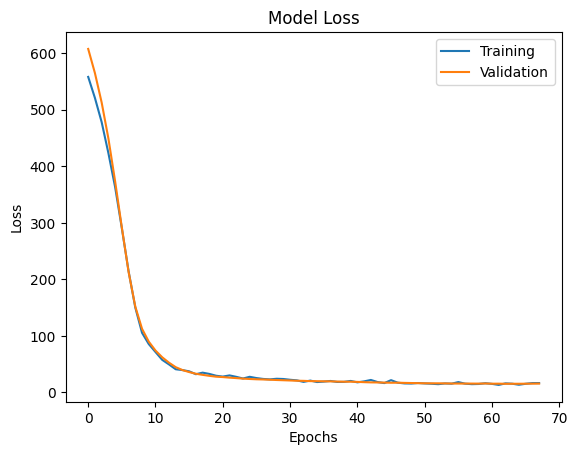

In [17]:
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

In [18]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test)

print("Mean Absolute Error:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 24.1613 - mean_absolute_error: 3.3810
Mean Absolute Error: 3.3809754848480225
